# XGBoost — Churn Prediction Model

Training an XGBoost classifier on the feature-engineered
churn dataset. XGBoost parallelizes tree building natively,
so tuning is much faster than sklearn's GradientBoosting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1 · Data Loading & Prep

Dropping features that leak the churn outcome:

| Feature | Why it leaks |
|:--------|:-------------|
| `Total_Net_Paid` | Churned = 0 (didn't pay — set after churn) |
| `price_change_pct/abs` | Derived from Total_Net_Paid |
| `net_paid_vs_last` | Ratio involving current payment (0 for churned) |
| `Payment_Method` | Set to UNKNOWN after churn |
| `Payment_Timeframe` | All churned = 0 |
| `Days_To_Close_Post_Renewal` | Uses close date (post-outcome) |
| `Total_Renewal_Score_New` | Composite encodes outcome |

In [3]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv")
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

# ---- DROP LEAKY FEATURES ------------------------------------------------
leaky_cols = [
    "Total_Net_Paid", "price_change_pct", "price_change_abs",
    "net_paid_vs_last", "Payment_Method", "Payment_Timeframe",
    "Days_To_Close_Post_Renewal", "Total_Renewal_Score_New",
    "Renewal_Year",
]
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
print(f"Dropped {len(leaky_cols)} leaky/non-predictive features")

# encode categoricals
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# class imbalance ratio for XGBoost
n_won = (y_train == 0).sum()
n_churned = (y_train == 1).sum()
scale_ratio = n_won / n_churned

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}  |  scale_pos_weight: {scale_ratio:.2f}")

Loaded shape: (122082, 61)
Dropped 9 leaky/non-predictive features

Features: 51
Train: 91115, Test: 22779
Churn rate: 11.12%  |  scale_pos_weight: 7.99


## 2 · Baseline XGBoost

In [4]:
xgb_base = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)
xgb_base.fit(X_train, y_train)

y_pred_base = xgb_base.predict(X_test)
y_prob_base = xgb_base.predict_proba(X_test)[:, 1]

print("=" * 60)
print("BASELINE XGBOOST RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_base):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE XGBOOST RESULTS
Accuracy  : 0.9293
Precision : 0.6220
Recall    : 0.9286
F1 Score  : 0.7450
ROC AUC   : 0.9809

              precision    recall  f1-score   support

         Won       0.99      0.93      0.96     20245
     Churned       0.62      0.93      0.74      2534

    accuracy                           0.93     22779
   macro avg       0.81      0.93      0.85     22779
weighted avg       0.95      0.93      0.94     22779



## 3 · Hyperparameter Tuning

Manual tuning — we test a few targeted configs instead of
doing exhaustive search. XGBoost is fast with n_jobs=-1
but we still want to be efficient.

In [5]:
from sklearn.model_selection import cross_val_score

configs = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 1.0},
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.01, "subsample": 0.9, "colsample_bytree": 0.8},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 1.0, "colsample_bytree": 1.0},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_config = None

for i, cfg in enumerate(configs):
    model = XGBClassifier(
        **cfg,
        scale_pos_weight=scale_ratio,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strat, scoring="f1")
    mean_f1 = scores.mean()
    print(f"Config {i+1}: F1={mean_f1:.4f} (+/- {scores.std():.4f})  {cfg}")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_config = cfg

print(f"\nBest config: {best_config}")
print(f"Best CV F1:  {best_f1:.4f}")

Config 1: F1=0.6986 (+/- 0.0064)  {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Config 2: F1=0.7481 (+/- 0.0028)  {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}
Config 3: F1=0.7372 (+/- 0.0055)  {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0}
Config 4: F1=0.7596 (+/- 0.0021)  {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Config 5: F1=0.6967 (+/- 0.0088)  {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.9, 'colsample_bytree': 0.8}
Config 6: F1=0.6992 (+/- 0.0063)  {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 1.0}

Best config: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best CV F1:  0.7596


## 4 · Best Model Evaluation

In [6]:
# train best config on full training set
best_xgb = XGBClassifier(
    **best_config,
    scale_pos_weight=scale_ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)
best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("=" * 60)
print("TUNED XGBOOST RESULTS")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED XGBOOST RESULTS
Accuracy  : 0.9333
Precision : 0.6398
Recall    : 0.9167
F1 Score  : 0.7536
ROC AUC   : 0.9810

              precision    recall  f1-score   support

         Won       0.99      0.94      0.96     20245
     Churned       0.64      0.92      0.75      2534

    accuracy                           0.93     22779
   macro avg       0.81      0.93      0.86     22779
weighted avg       0.95      0.93      0.94     22779



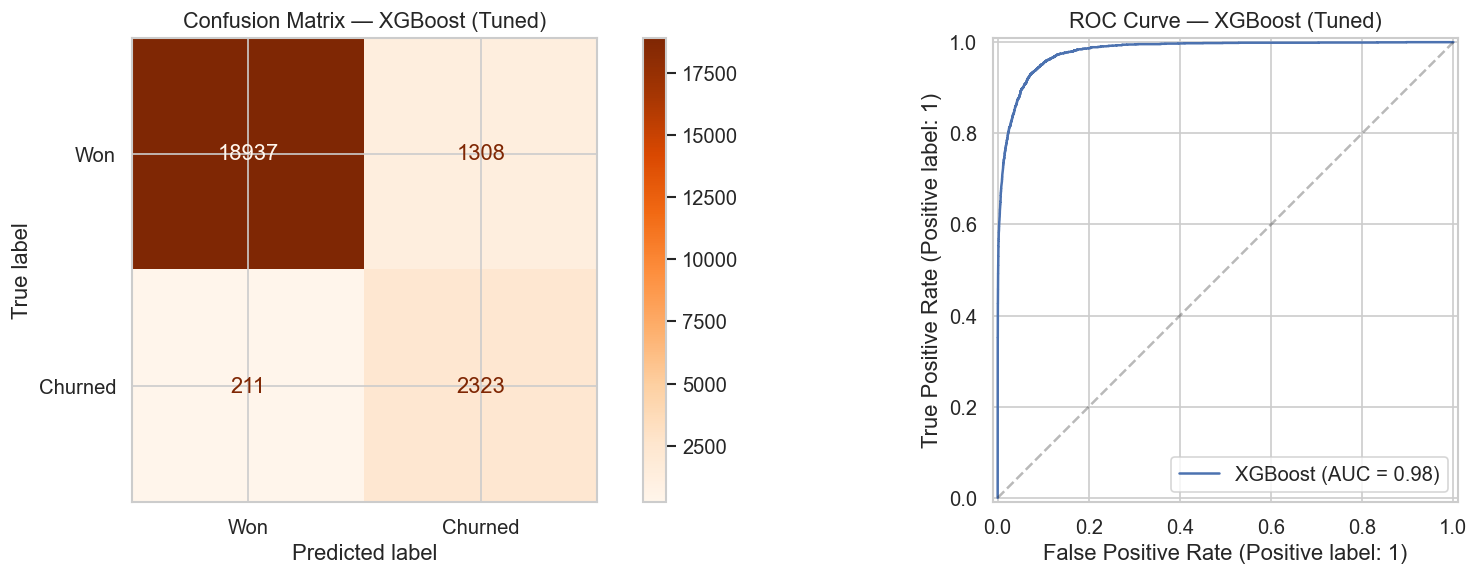

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Won", "Churned"], ax=axes[0],
    cmap="Oranges"
)
axes[0].set_title("Confusion Matrix — XGBoost (Tuned)", fontsize=13)

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name="XGBoost")
axes[1].set_title("ROC Curve — XGBoost (Tuned)", fontsize=13)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)

plt.tight_layout()
plt.show()

## 5 · Feature Importance

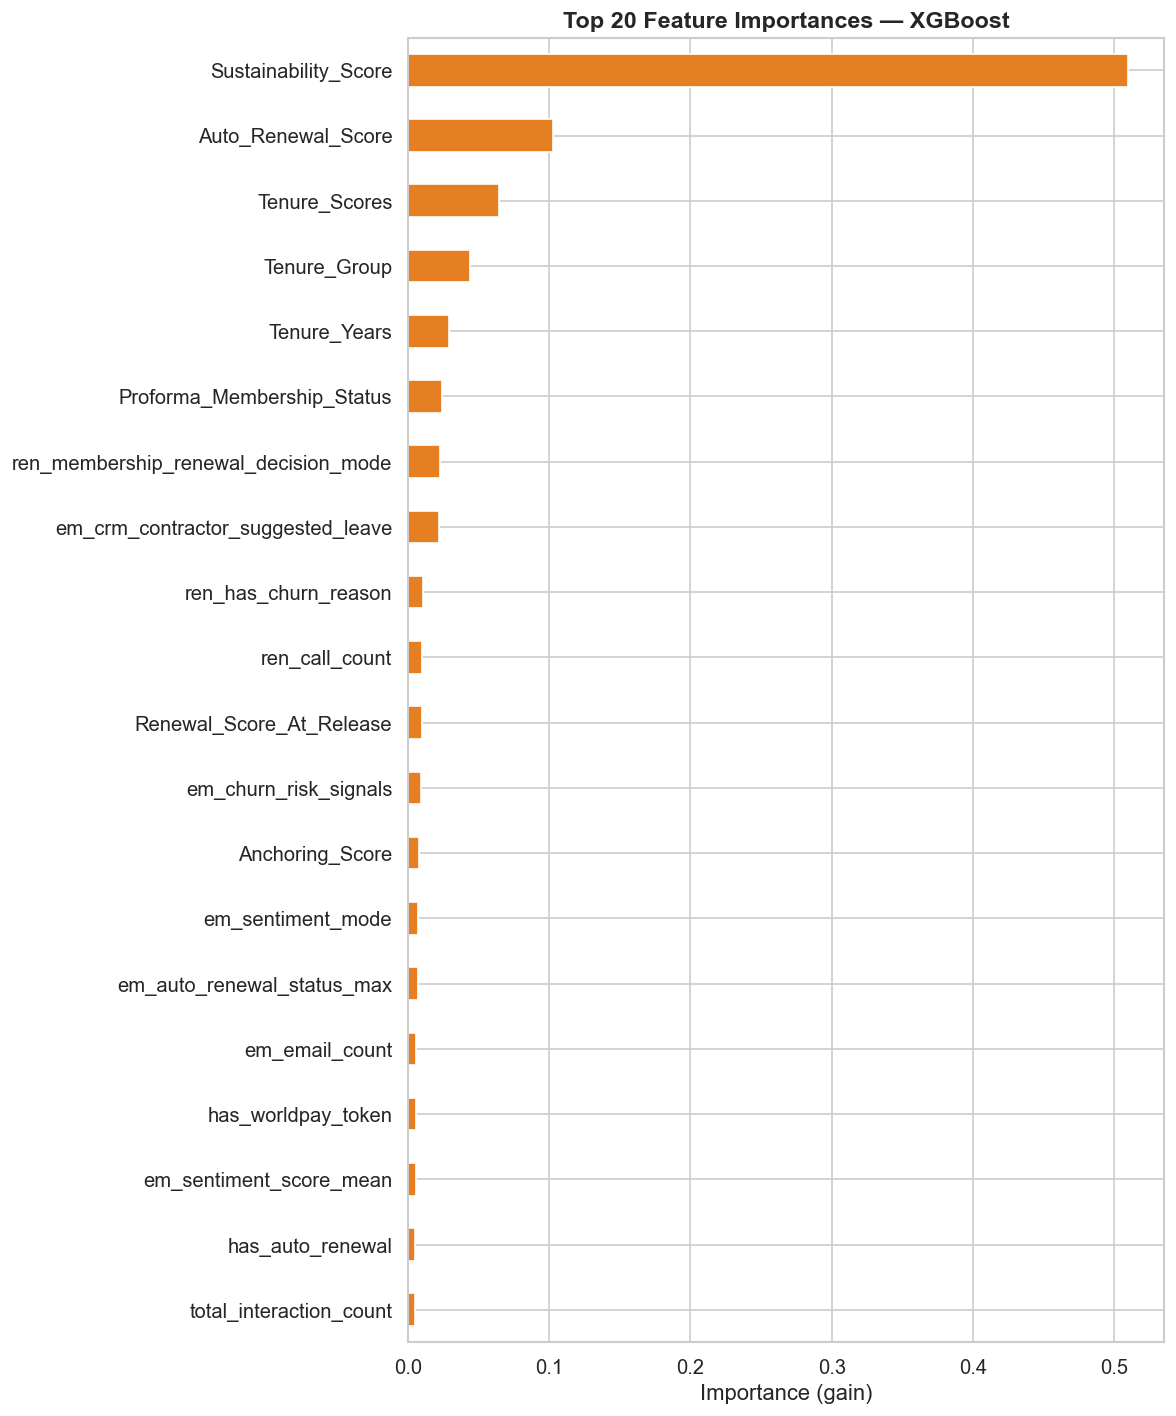

In [8]:
importances = best_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
feat_imp.tail(20).plot.barh(ax=ax, color="#e67e22", edgecolor="white")
ax.set_title("Top 20 Feature Importances — XGBoost", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

## Summary

| Metric | Baseline | Tuned |
|:-------|:---------|:------|
| Accuracy | — | — |
| Precision | — | — |
| Recall | — | — |
| F1 Score | — | — |
| ROC AUC | — | — |

*(Fill in after running the notebook)*